In [1]:

import subprocess, sys, os, importlib

# -- 0. Clone / pull repo ------------------------------------
REPO_URL = 'https://github.com/bishnt/PINN_for_transient_stability.git'
REPO_DIR = '/content/pinn-transient-stability'

if not os.path.exists(REPO_DIR):
    subprocess.run(['git', 'clone', REPO_URL, REPO_DIR], check=True)
else:
    subprocess.run(['git', 'pull'], cwd=REPO_DIR, check=True)

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q',
     'torch', 'numpy', 'scipy', 'matplotlib', 'tqdm', 'scikit-learn'],
    check=True
)

sys.path.insert(0, os.path.join(REPO_DIR, 'src'))
os.chdir(REPO_DIR)

# -- Print latest commits (useful to confirm stale-import issues) --
result = subprocess.run(
    ['git', 'log', '--oneline', '-3'],
    cwd=REPO_DIR, capture_output=True, text=True
)
print(f'[git] Latest commits:\n{result.stdout}')
print(f'[OK] Working directory: {os.getcwd()}')

# -- Force reload all project modules after pull --------------
for mod_name in ['swing_equation', 'data_generator', 'model', 'loss', 'trainer']:
    if mod_name in sys.modules:
        importlib.reload(sys.modules[mod_name])

[git] Latest commits:
badb9e5 fix(trainer): fix adam's convergence
68318af fix(trainer): initialization of weights
b673301 add(trainer): anchoring the loss weights for NTK approach

[OK] Working directory: /content/pinn-transient-stability


SMIB Parameters Initialized: SMIBParameters(H=5.0, D=0.05, omega0=376.99111843077515, Pm=0.8, Pmax=2.1, E=1.05, V=1.0)
Solver Initialized. Equilibrium Delta: 22.39 degrees

Generating reference trajectory for t_total=5.0s, dt=0.0001s...
Reference trajectory generated. Time points: 50001
Sample (t, delta, omega) from reference:
  t=0.000s, delta=22.39 deg, omega=376.99 rad/s
  t=2.500s, delta=345539.63 deg, omega=392.05 rad/s
  t=5.000s, delta=1198754.15 deg, omega=392.99 rad/s

Sampling training data: 5000 collocation, 100 data points...
--- Training Data Shapes ---
t_colloc: torch.Size([5000, 1]) (requires_grad=True)
t_data: torch.Size([100, 1]) (requires_grad=False)
delta_data: torch.Size([100, 1]) (requires_grad=False)
omega_data: torch.Size([100, 1]) (requires_grad=False)
t_ic: torch.Size([1, 1]) (requires_grad=False)
delta_ic: torch.Size([1, 1]) (requires_grad=False)
omega_ic: torch.Size([1, 1]) (requires_grad=False)

--- Initial Conditions Sample ---
t_ic: [0.]
delta_ic: 22.39 de

Adam: 100%|██████████| 12000/12000 [02:13<00:00, 90.21it/s, total=1.15e+00, physics=5.30e+00, data=7.47e-01, lr=7.8e-06]


Adam done. Final loss: 1.15e+00
  Final weights → physics: 0.050 | data: 1.000 | ic: 0.234
 Phase 2: L-BFGS Fine-Tuning


L-BFGS: 100%|██████████| 400/400 [00:39<00:00, 10.15it/s, total=1.15e+00]


L-BFGS done. Final loss: 1.15e+00
Model saved to models/pinn_trained.pt


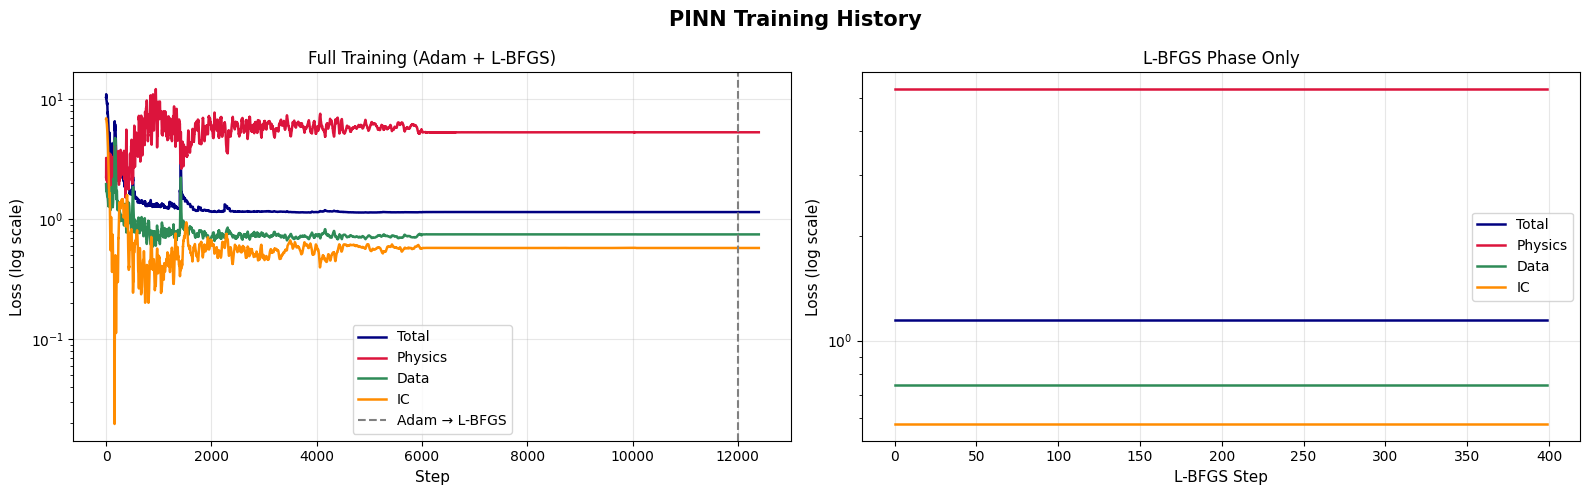

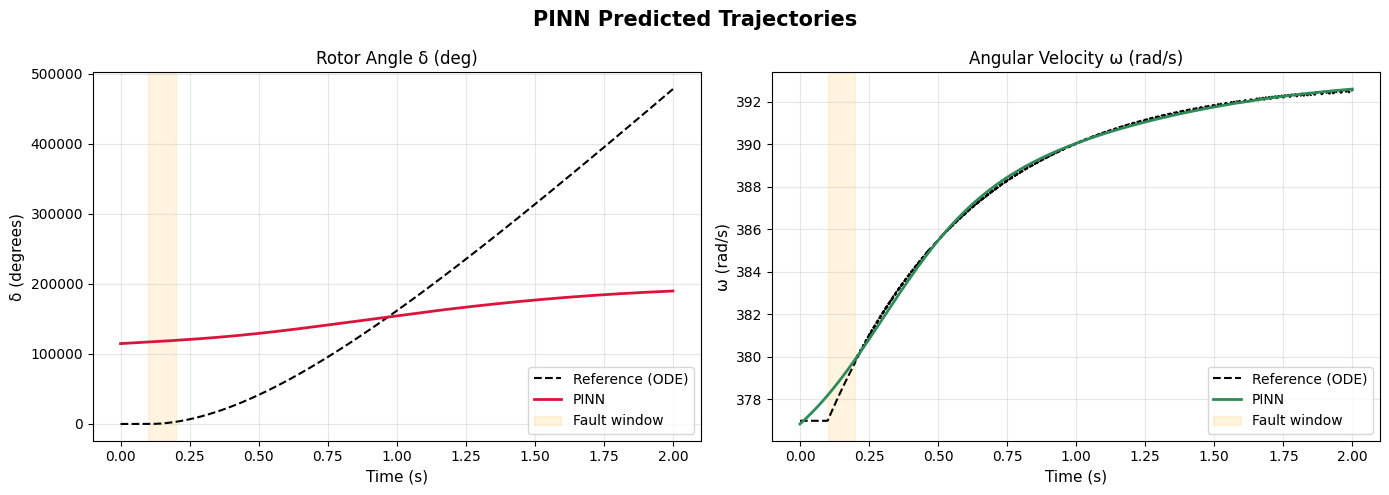

[OK] Training complete!


In [2]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from swing_equation import SMIBParameters
from data_generator import PINNDataGenerator
from model import PINN, count_parameters
from loss import PINNLoss
from trainer import PINNTrainer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Training on: {device}')

# -- 1. Fault / simulation constants (single source of truth) -
FAULT_START = 0.1
FAULT_END   = 0.2
T_TOTAL     = 2.0

# -- 2. Physics parameters ------------------------------------
params = SMIBParameters(H=5.0, D=0.05, Pm=0.8, Pmax=2.1)

# -- 3. Generate data -----------------------------------------
gen  = PINNDataGenerator(params, seed=42)
traj = gen.generate_reference_trajectory(
    fault_start=FAULT_START, fault_end=FAULT_END, t_total=T_TOTAL
)
# batch stays on CPU here; PINNTrainer.move_batch_to_device handles device + grad flags
batch = gen.sample_training_data(
    traj, n_collocation=5000, n_data_points=150
)

# -- 4. Build model -------------------------------------------
model = PINN(n_hidden_layers=4, n_neurons=64)
print(f'Trainable parameters: {count_parameters(model):,}')

# -- 5. Normalisation stats (computed on CPU before model.to(device)) --
delta_mean = batch['delta_data'].mean().item()
delta_std  = max(batch['delta_data'].std().item(), 1e-3)
omega_mean = batch['omega_data'].mean().item()
omega_std  = max(batch['omega_data'].std().item(), 1e-3)

print(f'Normalisation stats:')
print(f'  delta : mean={delta_mean:.4f}  std={delta_std:.4f}')
print(f'  omega : mean={omega_mean:.4f}  std={omega_std:.4f}')

model.set_normalizer(
    t_scale=T_TOTAL,
    delta_mean=delta_mean, delta_std=delta_std,
    omega_mean=omega_mean, omega_std=omega_std,
)
model.to(device)

# -- 6. Loss --------------------------------------------------
# All lambdas = 1.0 — PINNTrainer applies NTK-based adaptive weighting on top.
# Setting them != 1.0 here would cause double-weighting.
loss_fn = PINNLoss(
    params,
    lambda_phys=1.0,
    lambda_data=1.0,
    lambda_ic=1.0,
    fault_start=FAULT_START,
    fault_end=FAULT_END,
    fault_factor_pre=1.0,
    fault_factor_fault=0.0,
    fault_factor_post=1.0,
)

# -- 7. Train -------------------------------------------------
ADAM_EPOCHS  = 12000
LBFGS_EPOCHS = 400

trainer = PINNTrainer(model, loss_fn, device)
trainer.train_adam(batch, n_epochs=ADAM_EPOCHS,  lr=1e-3,  log_every=1000)
trainer.train_lbfgs(batch, n_epochs=LBFGS_EPOCHS, lr=0.05)

# -- 8. Save --------------------------------------------------
os.makedirs('models', exist_ok=True)
trainer.save_model('models/pinn_trained.pt')

# -- 9. Inference on test grid --------------------------------
t_test = gen.generate_test_grid(t_total=T_TOTAL, n_points=1000).to(device)

with torch.no_grad():
    predictions = model(t_test)

    # Slice the tensor: all rows, column 0 for delta, column 1 for omega
    delta_pred = predictions[:, 0].cpu().numpy()
    omega_pred = predictions[:, 1].cpu().numpy()
    t_np = t_test.cpu().numpy()

# -- 10. Plots ------------------------------------------------
os.makedirs('results/plots', exist_ok=True)

# --- 10a. Training history ---
ADAM_STEPS  = ADAM_EPOCHS
TOTAL_STEPS = ADAM_EPOCHS + LBFGS_EPOCHS

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('PINN Training History', fontsize=15, fontweight='bold')

colors = {'total': 'navy', 'physics': 'crimson', 'data': 'seagreen', 'ic': 'darkorange'}
labels = {'total': 'Total', 'physics': 'Physics', 'data': 'Data', 'ic': 'IC'}

# Left: full history
ax = axes[0]
for key in ['total', 'physics', 'data', 'ic']:
    ax.semilogy(trainer.history[key], color=colors[key], linewidth=1.8, label=labels[key])
ax.axvline(x=ADAM_STEPS, color='gray', linestyle='--', linewidth=1.5, label='Adam → L-BFGS')
ax.set_title('Full Training (Adam + L-BFGS)', fontsize=12)
ax.set_xlabel('Step', fontsize=11)
ax.set_ylabel('Loss (log scale)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Right: L-BFGS phase only
ax = axes[1]
for key in ['total', 'physics', 'data', 'ic']:
    ax.semilogy(trainer.history[key][ADAM_STEPS:], color=colors[key], linewidth=1.8, label=labels[key])
ax.set_title('L-BFGS Phase Only', fontsize=12)
ax.set_xlabel('L-BFGS Step', fontsize=11)
ax.set_ylabel('Loss (log scale)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/training_history.png', dpi=150)
plt.show()

# --- 10b. Predicted trajectories ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('PINN Predicted Trajectories', fontsize=15, fontweight='bold')

t_ref   = traj['t']
d_ref   = traj['delta']
w_ref   = traj['omega']

axes[0].plot(t_ref,  np.degrees(d_ref),  'k--', linewidth=1.5, label='Reference (ODE)')
axes[0].plot(t_np,   np.degrees(delta_pred), color='crimson', linewidth=2, label='PINN')
axes[0].axvspan(FAULT_START, FAULT_END, alpha=0.12, color='orange', label='Fault window')
axes[0].set_title('Rotor Angle δ (deg)', fontsize=12)
axes[0].set_xlabel('Time (s)', fontsize=11)
axes[0].set_ylabel('δ (degrees)', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_ref,  w_ref,       'k--', linewidth=1.5, label='Reference (ODE)')
axes[1].plot(t_np,   omega_pred,  color='seagreen', linewidth=2, label='PINN')
axes[1].axvspan(FAULT_START, FAULT_END, alpha=0.12, color='orange', label='Fault window')
axes[1].set_title('Angular Velocity ω (rad/s)', fontsize=12)
axes[1].set_xlabel('Time (s)', fontsize=11)
axes[1].set_ylabel('ω (rad/s)', fontsize=11)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('results/plots/predicted_trajectories.png', dpi=150)
plt.show()

print('[OK] Training complete!')